In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import pandas as pd
frozenshrimp = {'Year': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22','2022-23'],'Quantity': [95724,105427,101318,102484,110275,111874,127709,134815,129768,138085,145180,137397,136223,126039,130553,151465,189125,228620,301435,357505,373866,434486,565980,614145,652253,590275,728123,711099],
'Price': [2356.81,2701.76,3140.56,3344.91,3645.22,4481.51,4139.92,4608.31,4013.07,4220.67,4271.51,4506.08,3941.62,3779.8,4182.35,5718.13,8175.26,9706.36,19368.3,22468.12,20045.5,24711.32,30868.17,31800.51,34152.03,32525.29,42706.04,43135.58]}
df1=pd.DataFrame(frozenshrimp)


Dataset has 28 records and 3 columns


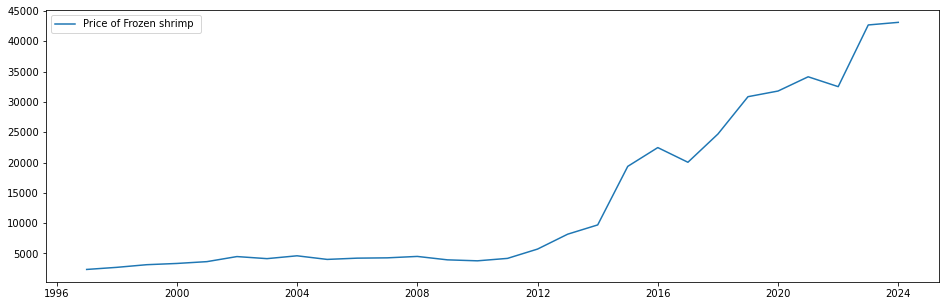

Results of Dickey-Fuller Test:
Test Statistic                  1.431195
p-value                         0.997251
#Lags Used                      0.000000
Number of Observations Used    27.000000
Critical Value (1%)            -3.699608
Critical Value (5%)            -2.976430
Critical Value (10%)           -2.627601
dtype: float64


In [3]:
# Check the dimensionality of the dataset
df1.shape
print("Dataset has {} records and {} columns".format(df1.shape[0], df1.shape[1]))
# Changing the YEAR data type and setting it as index
df1['YEAR'] = pd.Index(sm.tsa.datetools.dates_from_range('1996', '2023'))
df1.index = df1['YEAR']
# Check the data type
del df1['YEAR']
# View the dataset
df1.head()
# Plotting the Data
# Define the plot size
plt.figure(figsize=(16,5))
# Plot the data
plt.plot(df1.index, df1['Price'], label = "Price of Frozen shrimp ")
plt.legend(loc='best')
plt.show()
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df1test = adfuller(timeseries, autolag='AIC')
    df1output = pd.Series(df1test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df1test[4].items():
        df1output['Critical Value (%s)'%key] = value
    print (df1output)
# Call the function and run the test

adf_test(df1['Price'])


In [4]:
df1['Price_diff'] =df1['Price'].diff()
df1= df1.dropna()


In [53]:
#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df1test = adfuller(df1['Price_diff'],autolag='AIC')
df1output=pd.Series(df1test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df1test[4].items():
    df1output['critical value (%s)'%key]= value
print(df1output)

Results of Dickey-fuller test:
Test Statistic :                 -3.640257
p-value :                         0.005036
#lags used :                      9.000000
number of observations used :    17.000000
critical value (1%)              -3.889266
critical value (5%)              -3.054358
critical value (10%)             -2.666984
dtype: float64


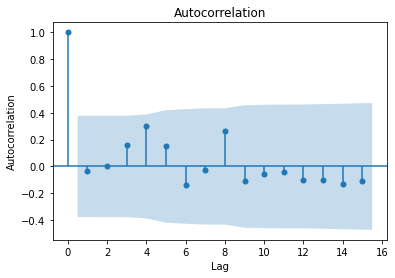

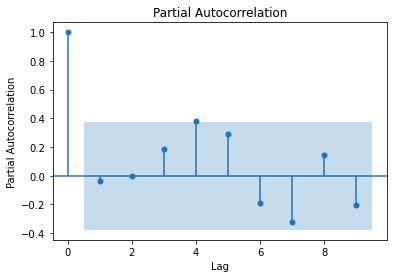

In [54]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df1['Price_diff'].values
#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()
# Plot the PACF
plot_pacf(values,lags=9)
plt.ylabel('Partial Autocorrelation')
plt.xlabel('Lag')
plt.show()

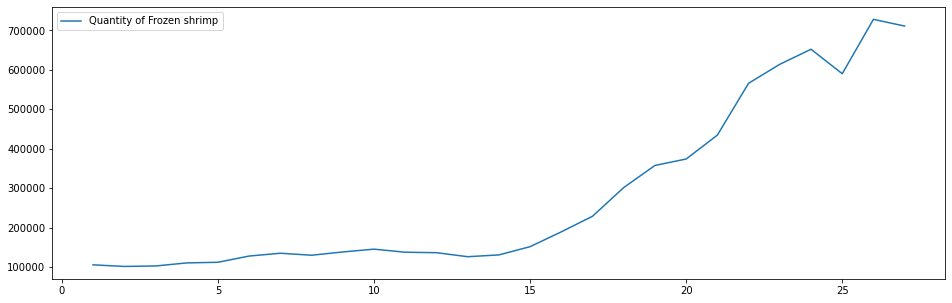

Results of Dickey-Fuller Test:
Test Statistic                 -1.177226
p-value                         0.683315
#Lags Used                      4.000000
Number of Observations Used    22.000000
Critical Value (1%)            -3.769733
Critical Value (5%)            -3.005426
Critical Value (10%)           -2.642501
dtype: float64


In [55]:
# Check the dimensionality of the dataset
df1.shape
df1.head()
# Plotting the Data
# Define the plot size
plt.figure(figsize=(16,5))
# Plot the data
plt.plot(df1.index, df1['Quantity'], label = "Quantity of Frozen shrimp")
plt.legend(loc='best')
plt.show()
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df1test = adfuller(timeseries, autolag='AIC')
    df1output = pd.Series(df1test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df1test[4].items():
        df1output['Critical Value (%s)'%key] = value
    print (df1output)
# Call the function and run the test

adf_test(df1['Quantity'])


In [56]:
df1['Quantity_diff'] =df1['Quantity'].diff()
df1= df1.dropna()


In [57]:
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df1test = adfuller(timeseries, autolag='AIC')
    df1output = pd.Series(df1test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df1test[4].items():
        df1output['Critical Value (%s)'%key] = value
    print (df1output)
# Call the function and run the test

adf_test(df1['Quantity_diff'])

Results of Dickey-Fuller Test:
Test Statistic                 -0.996963
p-value                         0.754370
#Lags Used                      3.000000
Number of Observations Used    22.000000
Critical Value (1%)            -3.769733
Critical Value (5%)            -3.005426
Critical Value (10%)           -2.642501
dtype: float64


In [58]:
df1['Quantity_diff_2'] =df1['Quantity_diff'].diff()
df1= df1.dropna()


In [59]:

# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df1test = adfuller(timeseries, autolag='AIC')
    df1output = pd.Series(df1test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df1test[4].items():
        df1output['Critical Value (%s)'%key] = value
    print (df1output)
# Call the function and run the test

adf_test(df1['Quantity_diff_2'])



Results of Dickey-Fuller Test:
Test Statistic                -6.992571e+00
p-value                        7.677576e-10
#Lags Used                     2.000000e+00
Number of Observations Used    2.200000e+01
Critical Value (1%)           -3.769733e+00
Critical Value (5%)           -3.005426e+00
Critical Value (10%)          -2.642501e+00
dtype: float64


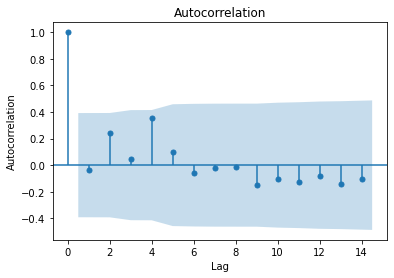

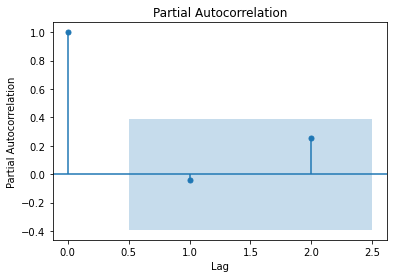

In [60]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df1['Quantity_diff'].values

#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()
# Plot the PACF
plot_pacf(values,lags=2)
plt.ylabel('Partial Autocorrelation')
plt.xlabel('Lag')
plt.show()

In [20]:
#2 nd objectieve
#Estimate the cointegrating relationship using OLS

# Add a constant column to the independent variable
variable1_with_constant = sm.add_constant(df1['Quantity'])

# Fit the OLS model
model = sm.OLS(df1['Price'], variable1_with_constant)
result = model.fit()

# Get the estimated coefficients
intercept = result.params[0]
slope = result.params[1]

# Print the results
print("Cointegrating Relationship:")
print("Price = {} + {} * Quantity".format(intercept, slope))
print("\nOLS Summary:")
print(result.summary())


Cointegrating Relationship:
Price = -3541.0352066133382 + 0.06233076258767876 * Quantity

OLS Summary:
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     1608.
Date:                Sun, 16 Jul 2023   Prob (F-statistic):           8.64e-23
Time:                        20:15:29   Log-Likelihood:                -219.95
No. Observations:                  25   AIC:                             443.9
Df Residuals:                      23   BIC:                             446.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

In [21]:
#2 nd objectieve
#Estimate the cointegrating relationship using OLS

# Add a constant column to the independent variable
variable1_with_constant = sm.add_constant(df1['Quantity_diff_2'])

# Fit the OLS model
model = sm.OLS(df1['Price_diff'], variable1_with_constant)
result = model.fit()

# Get the estimated coefficients
intercept = result.params[0]
slope = result.params[1]

# Print the results
print("Cointegrating Relationship:")
print("Price = {} + {} * Quantity".format(intercept, slope))
print("\nOLS Summary:")
print(result.summary())


Cointegrating Relationship:
Price = 1617.2186636186132 + 0.03371634459661866 * Quantity

OLS Summary:
                            OLS Regression Results                            
Dep. Variable:             Price_diff   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     19.43
Date:                Sun, 16 Jul 2023   Prob (F-statistic):           0.000204
Time:                        20:16:17   Log-Likelihood:                -228.27
No. Observations:                  25   AIC:                             460.5
Df Residuals:                      23   BIC:                             463.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------

In [62]:
# 3rd obj VAR model
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR

# Extract the variables of interest
variables = df1[['Quantity', 'Price']]

# Create a VAR model with a specified lag order (p)
model = VAR(variables)
results = model.fit(maxlags=2) 
print(model)
parameters = results.params
print("Parameter Estimates:")
print(parameters)
print("\n")
# Print the estimated coefficients
print("Estimated Coefficients:")
print(results.coefs)

# Forecast future values
n_periods = 10  # Number of periods to forecast
forecast = results.forecast(variables.values[-2:], steps=n_periods)  # Specify the appropriate lag order

# Print the forecasted values
print("Forecasted Values:")
print(forecast)



Parameter Estimates:
                 Quantity       Price
const        49550.865499  969.542944
L1.Quantity      0.051759   -0.040104
L1.Price         9.900253    1.283705
L2.Quantity      0.256797    0.034783
L2.Price         3.129317   -0.072778


Estimated Coefficients:
[[[ 0.05175927  9.90025312]
  [-0.04010389  1.28370459]]

 [[ 0.25679726  3.12931686]
  [ 0.03478312 -0.07277758]]]
Forecasted Values:
[[ 834030.71184755   50043.39326211]
 [ 905755.11751274   53357.53606716]
 [ 995463.63605418   58508.7028519 ]
 [1079894.37216073   63777.22170962]
 [1175580.65031806   69899.89493596]
 [1279317.76332719   76475.54067417]
 [1393519.43619607   83639.1390496 ]
 [1517568.55380571   91384.89223856]
 [1652418.00835197   99804.23962071]
 [1798845.77714513  108955.30442547]]


In [1]:
import pandas as pd
frozenshrimp = {'Year': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22','2022-23'],'Quantity': [95724,105427,101318,102484,110275,111874,127709,134815,129768,138085,145180,137397,136223,126039,130553,151465,189125,228620,301435,357505,373866,434486,565980,614145,652253,590275,728123,711099],
'Price': [2356.81,2701.76,3140.56,3344.91,3645.22,4481.51,4139.92,4608.31,4013.07,4220.67,4271.51,4506.08,3941.62,3779.8,4182.35,5718.13,8175.26,9706.36,19368.3,22468.12,20045.5,24711.32,30868.17,31800.51,34152.03,32525.29,42706.04,43135.58]}
df1=pd.DataFrame(frozenshrimp)


In [16]:
# Assuming you have a DataFrame 'data' containing the price and quantity variables.
# We'll use the ADF test to check for stationarity.
from statsmodels.tsa.stattools import adfuller
data=df1[['Price','Quantity']]
def are_series_stationary(data, threshold=0.05):
    result = adfuller(data)
    p_value = result[1]
    return p_value <= threshold

# Test for stationarity of price and quantity
is_price_stationary = are_series_stationary(df1['Price'])
is_quantity_stationary = are_series_stationary(df1['Quantity'])

# If both series are non-stationary, proceed with cointegration test
if not is_price_stationary and not is_quantity_stationary:
    result = coint_johansen(data, det_order=0, k_ar_diff=1)

    # Get the trace statistics and critical values for different significance levels (e.g., 90%, 95%, 99%)
    trace_statistic = result.lr1
    trace_critical_values = result.cvt[:, 1]  # Use 1% critical value (you can choose other values as well)

    # Find the number of cointegrated vectors (relationships)
    num_cointegrated_vectors = sum(trace_statistic > trace_critical_values)

    if num_cointegrated_vectors > 0:
        print("The variables price and quantity are cointegrated.")
    else:
        print("The variables price and quantity are not cointegrated.")
else:
    print("Both variables should be non-stationary for cointegration testing.")


The variables price and quantity are cointegrated.


In [10]:
trace_statistic

array([13.40180288,  4.32595092])

In [11]:
 trace_critical_values

array([15.4943,  3.8415])

In [12]:
trace_statistic > trace_critical_values


array([False,  True])

In [13]:
 num_cointegrated_vectors

1

In [6]:
import pandas as pd
import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

# Extract the variables
variables = df1[[ 'Quantity','Price']]

# Perform Johansen cointegration test
coint_result = coint_johansen(variables, det_order=-1, k_ar_diff=1)

# Extract the cointegrating vectors
coint_vectors = coint_result.evec

# Specify the number of cointegrating vectors to use for prediction
num_coint_vectors = 1

# Create the VECM model using the cointegrating vectors
model = VECM(variables, k_ar_diff=1, coint_rank=num_coint_vectors, deterministic='nc')
model_fit = model.fit()
print(model)
# Generate predictions for the next 'n' steps
n = 10
forecast = model_fit.predict(steps=10)

# Print the forecasted values
print("Forecasted Values:")
print(forecast)
model_fit.predict(10, 0.05)

Forecasted Values:
[[ 791042.84715135   49452.3742122 ]
 [ 854681.9846994    53730.5469815 ]
 [ 924784.15658751   58754.25915696]
 [1001425.49035184   64210.20397681]
 [1084068.33075674   70087.86296395]
 [1173514.41005627   76452.64356208]
 [1270290.9906104    83338.44464545]
 [1374991.13019864   90788.01834812]
 [1488267.25929068   98847.81669777]
 [1610821.22988168  107567.74198945]]


C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency A-DEC will be used.
  warnings.warn('No frequency information was'


(array([[ 791042.84715135,   49452.3742122 ],
        [ 854681.9846994 ,   53730.5469815 ],
        [ 924784.15658751,   58754.25915696],
        [1001425.49035184,   64210.20397681],
        [1084068.33075674,   70087.86296395],
        [1173514.41005627,   76452.64356208],
        [1270290.9906104 ,   83338.44464545],
        [1374991.13019864,   90788.01834812],
        [1488267.25929068,   98847.81669777],
        [1610821.22988168,  107567.74198945]]),
 array([[ 711150.44548047,   44030.57134745],
        [ 749915.44272407,   46660.20076606],
        [ 796311.08903401,   50162.01835551],
        [ 849434.13902662,   54122.79885501],
        [ 908555.88803212,   58514.39777235],
        [ 973889.82352746,   63358.21624432],
        [1045649.31251111,   68664.18546687],
        [1124162.9019811 ,   74454.44776112],
        [1209844.85036028,   80756.94883679],
        [1303174.83202062,   87604.39873987]]),
 array([[ 870935.24882223,   54874.17707694],
        [ 959448.52667473,   6

In [5]:
vecm_res = model.fit()
vecm_res.gamma.round(4)
vecm_res.summary()
print(model)
vecm_res.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
L1.Quantity,-0.4727,0.389,-1.216,0.224,-1.235,0.289
L1.Price,3.6984,5.163,0.716,0.474,-6.421,13.818
,coef,std err,z,P>|z|,[0.025,0.975]
L1.Quantity,-0.0387,0.026,-1.470,0.142,-0.090,0.013
L1.Price,0.1867,0.350,0.534,0.594,-0.499,0.872
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,0.1044,0.034,3.026,0.002,0.037,0.172
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,0.0083,0.002,3.554,0.000,0.004,0.013
,coef,std err,z,P>|z|,[0.025,0.975]


lower bounds of confidence intervals:
[[712438.105  44142.267]
 [751613.605  46814.537]
 [798347.132  50357.337]
 [851814.854  54359.525]
 [911269.161  58792.19 ]]

point forecasts:
[[ 790898.938   49458.966]
 [ 854463.852   53749.306]
 [ 924415.117   58784.648]
 [1000930.788   64255.19 ]
 [1083425.175   70147.483]]

upper bounds of confidence intervals:
[[ 869359.772   54775.665]
 [ 957314.1     60684.075]
 [1050483.103   67211.959]
 [1150046.722   74150.855]
 [1255581.19    81502.775]]


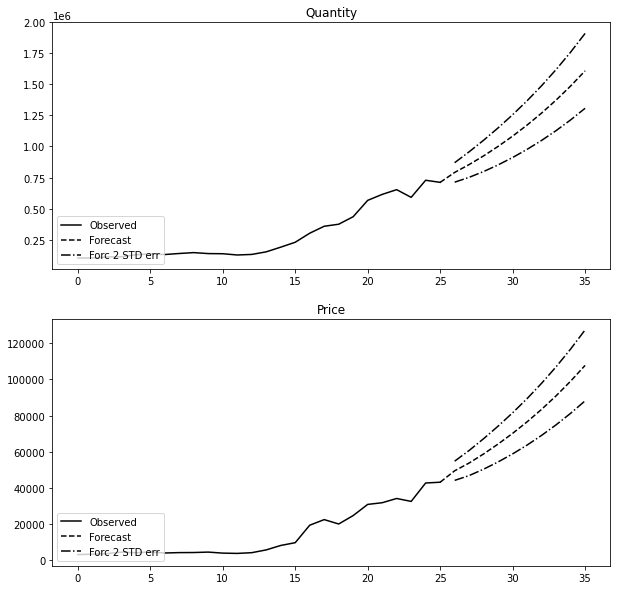

In [6]:
vecm_res.predict(steps=5)
forecast, lower, upper = vecm_res.predict(5, 0.05)
print("lower bounds of confidence intervals:")
print(lower.round(3))
print("\npoint forecasts:")
print(forecast.round(3))
print("\nupper bounds of confidence intervals:")
print(upper.round(3))
vecm_res.plot_forecast(steps=10)
